# EDA


### Librerias

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

### Cargar datos

In [2]:
## ARREGLAR

data_path = r"C:\Users\edo\Desktop\Simulacion Empresarial\Bronze_BANK_marketing_190126.csv"

In [3]:
# Cargar el dataset con separador y encoding correctos
df = pd.read_csv(
    data_path,
    sep=";",
    encoding="utf-8"
)


## Resumen del Bloque 1 y 2

### Calidad de los Datos
El análisis inicial muestra que el dataset presenta una estructura consistente, con variables numéricas y categóricas correctamente definidas. Se detectan valores nulos explícitos en las variables *education* (7 registros) y *marital* (5 registros), los cuales deberán considerarse en etapas posteriores del análisis.

### Estadísticas Descriptivas
Las estadísticas descriptivas evidencian una alta variabilidad en algunas variables numéricas, especialmente en aquellas relacionadas con el *balance* y la *duración*, lo que sugiere la posible presencia de valores extremos en el conjunto de datos.

### Limitaciones Iniciales
En las variables categóricas se observa la presencia de valores *"unknown"* en campos como *poutcome* (7886 unknown), *contact* (2197), *education** (473) y *job* (68). Esta característica representa una limitación inicial que deberá ser tratada o evaluada según los objetivos del análisis.




## 1. DATA QUALITY - resúmenes estadísticos de las variables

#### 1.1 estructura general

In [4]:
# Dimensiones del dataset
df.shape

(10643, 18)

In [5]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
2,3,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
3,4,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
4,5,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes


In [6]:
# Info general del dataset y tipos de datos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10643 entries, 0 to 10642
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         10643 non-null  int64 
 1   age        10643 non-null  int64 
 2   job        10643 non-null  object
 3   marital    10638 non-null  object
 4   education  10636 non-null  object
 5   default    10643 non-null  object
 6   balance    10643 non-null  int64 
 7   housing    10643 non-null  object
 8   loan       10643 non-null  object
 9   contact    10643 non-null  object
 10  day        10643 non-null  int64 
 11  month      10643 non-null  object
 12  duration   10643 non-null  int64 
 13  campaign   10643 non-null  int64 
 14  pdays      10643 non-null  int64 
 15  previous   10643 non-null  int64 
 16  poutcome   10643 non-null  object
 17  deposit    10643 non-null  object
dtypes: int64(8), object(10)
memory usage: 1.5+ MB


#### 1.2 resumen variables numericas


In [7]:
numeric_cols = df.select_dtypes(include="number").columns.difference(["id"])

global_numeric_stats = df[numeric_cols].describe().T

global_numeric_stats


,count,mean,std,min,25%,50%,75%,max
age,10643.0,41.219393,12.058387,0.0,32.0,39.0,49.0,95.0
balance,10643.0,1536.690595,3223.277326,-6847.0,127.0,558.0,1729.5,81204.0
campaign,10643.0,2.496007,2.694572,1.0,1.0,2.0,3.0,63.0
day,10643.0,15.644461,8.433109,1.0,8.0,15.0,22.0,31.0
duration,10643.0,378.755520,351.223266,2.0,141.0,260.0,510.0,3881.0
pdays,10643.0,52.068684,109.204969,-1.0,-1.0,-1.0,57.5,854.0
previous,10643.0,0.851264,2.321661,0.0,0.0,0.0,1.0,58.0


#### 1.3 resumen variables categóricas


In [8]:
def resumen_variables_categoricas(dataframe):
    """
    Genera un resumen de variables categóricas:
    - número de categorías
    - valor más frecuente
    - porcentaje del valor más frecuente
    """
    categorical_columns = dataframe.select_dtypes(
        include=["object", "category"]
    ).columns

    resumen_categorico = []

    total_rows = len(dataframe)

    for column in categorical_columns:
        value_counts = dataframe[column].value_counts(dropna=False)

        most_frequent_value = value_counts.index[0]
        most_frequent_percentage = (value_counts.iloc[0] / total_rows) * 100
        unique_categories = dataframe[column].nunique(dropna=False)

        resumen_categorico.append({
            "variable": column,
            "unique_categories": unique_categories,
            "most_frequent_value": most_frequent_value,
            "most_frequent_percentage": round(most_frequent_percentage, 2)
        })

    resumen_categorico_df = pd.DataFrame(resumen_categorico)

    return resumen_categorico_df


In [9]:
# Aplico resumen_variables_categoricas a df
categorical_summary = resumen_variables_categoricas(df)

categorical_summary

,variable,unique_categories,most_frequent_value,most_frequent_percentage
0,job,12,management,22.99
1,marital,4,married,56.67
2,education,5,secondary,49.02
3,default,2,no,98.54
4,housing,2,no,53.18
5,loan,2,no,87.11
6,contact,3,cellular,72.41
7,month,12,may,24.87
8,poutcome,4,unknown,74.10
9,deposit,2,no,50.30


## 2. LIMITATIONS - valores nulos y unkwown


#### 2.1 missing data


In [10]:
def resumen_missing_data(dataframe):
    """
    Genera un resumen de valores missing por columna
    """
    # Conteo de valores nulos por columna
    missing_count = dataframe.isna().sum()

    # Porcentaje de valores nulos
    missing_percentage = ((missing_count / len(dataframe)) * 100).round(2)

    # Crear DataFrame resumen (DataFrame con D mayúscula)
    missing_summary_df = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percentage": missing_percentage
    }).sort_values(
        by="missing_percentage",
        ascending=False
    )

    return missing_summary_df


In [11]:
# aplicar resumen_missing_data dataset 
missing_summary = resumen_missing_data(df)

missing_summary


,missing_count,missing_percentage
education,7,0.07
marital,5,0.05
age,0,0.00
id,0,0.00
job,0,0.00
default,0,0.00
balance,0,0.00
housing,0,0.00
loan,0,0.00
contact,0,0.00


#### 2.2 valores unknown

In [12]:
def resumen_unknown_values(dataframe):
    """
    Cuenta valores 'unknown' por columna
    """
    unknown_count = (dataframe == "unknown").sum()

    unknown_summary_df = (
        unknown_count[unknown_count > 0]
        .to_frame(name="unknown_count")
        .sort_values(by="unknown_count", ascending=False)
    )

    return unknown_summary_df

In [13]:
# aplicar resumen_unknown_values a df
unknown_summary = resumen_unknown_values(df)
unknown_summary


,unknown_count
poutcome,7886
contact,2197
education,473
job,68


## 3. DISTRIBUTIONS - gráficos de distribución de datos

#### 3.1 Visualicacion de datos numericos

In [14]:
def auto_visualize_dataframe_histplot(df):    
    for column in df.columns:
        
        if pd.api.types.is_numeric_dtype(df[column]):
            plt.figure(figsize=(10, 5))
            sns.histplot(df[column], kde=True)
            plt.title(f"Distribución {column}")
            plt.xlabel(column)
            plt.ylabel("Frecuencia")

            median = df[column].median()
            plt.axvline(median, color="green", linestyle="-", label=f"Median: {median:.1f}")

            mean = df[column].mean()
            plt.axvline(mean, color="red", linestyle="--", label=f"Mean: {mean:.1f}")
            
            plt.show()

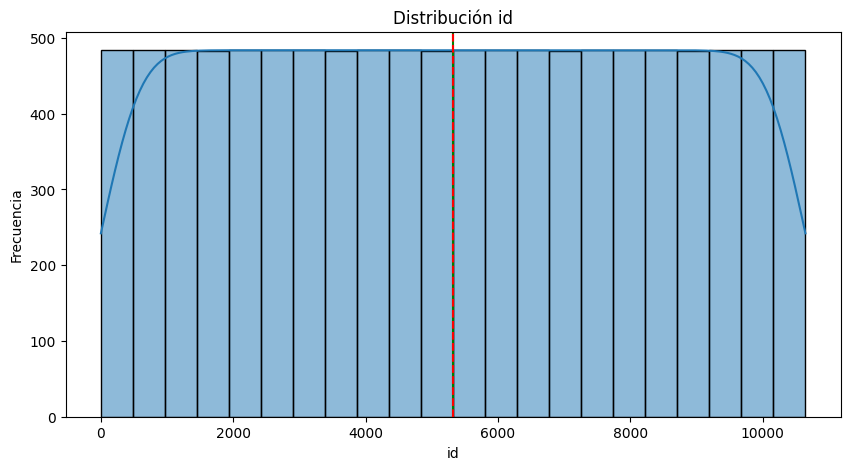

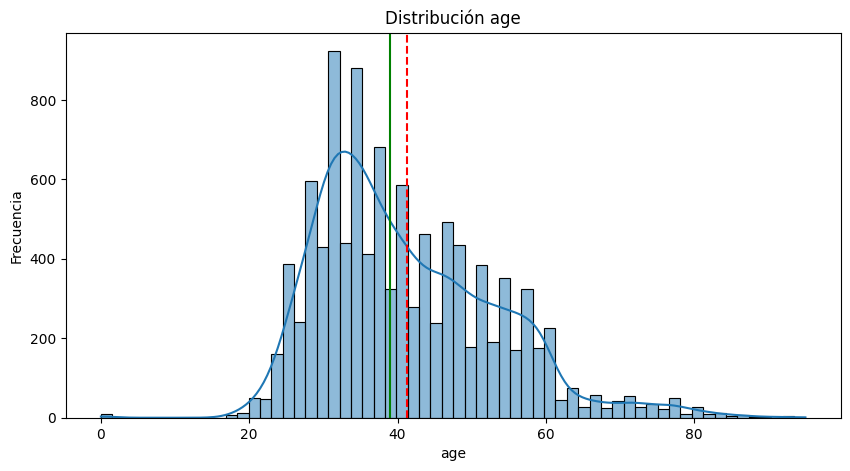

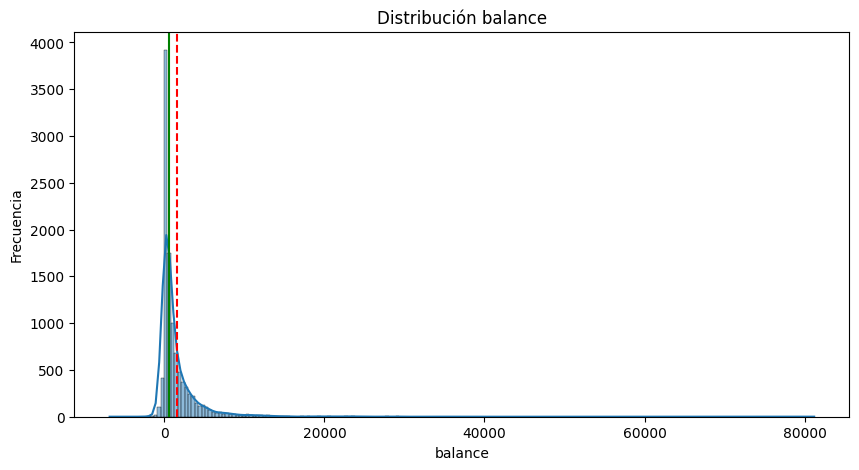

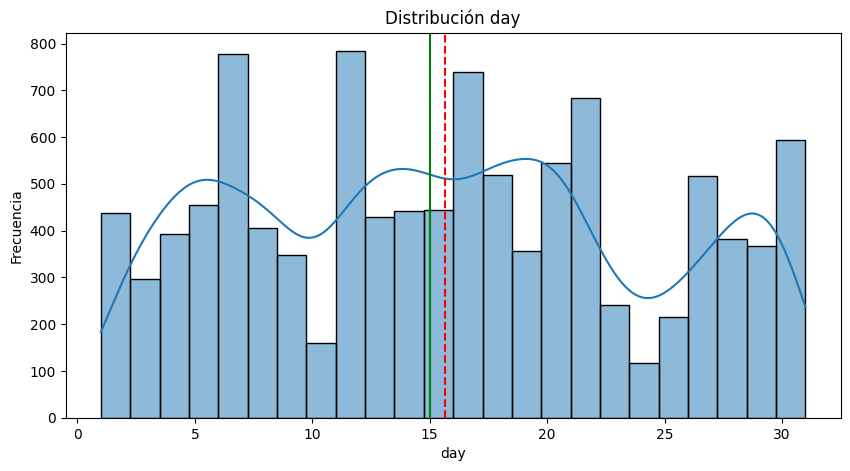

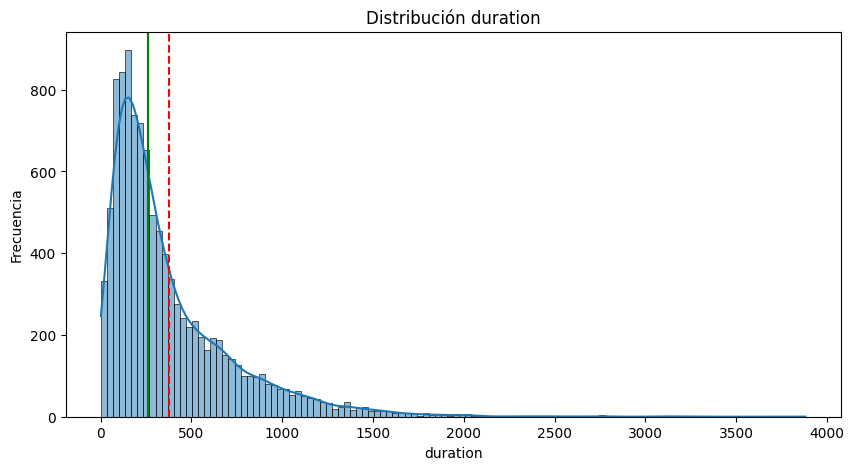

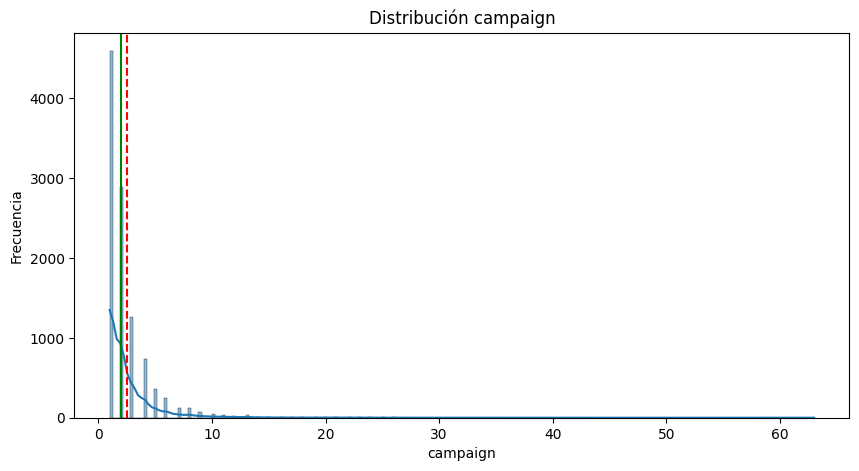

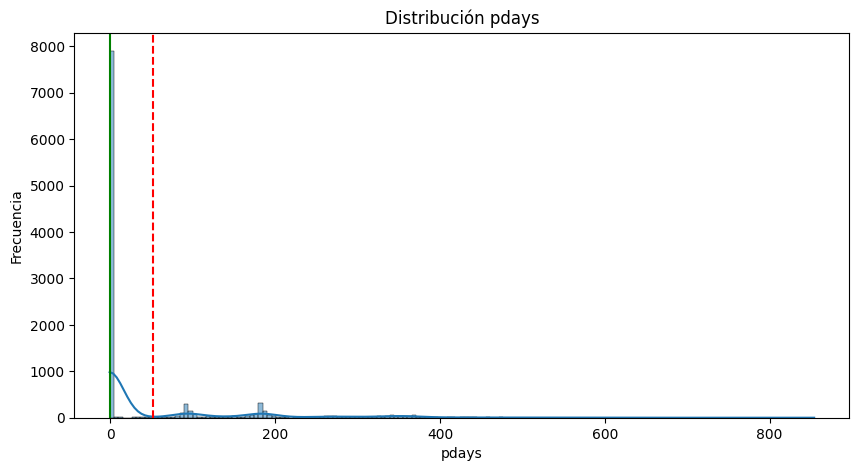

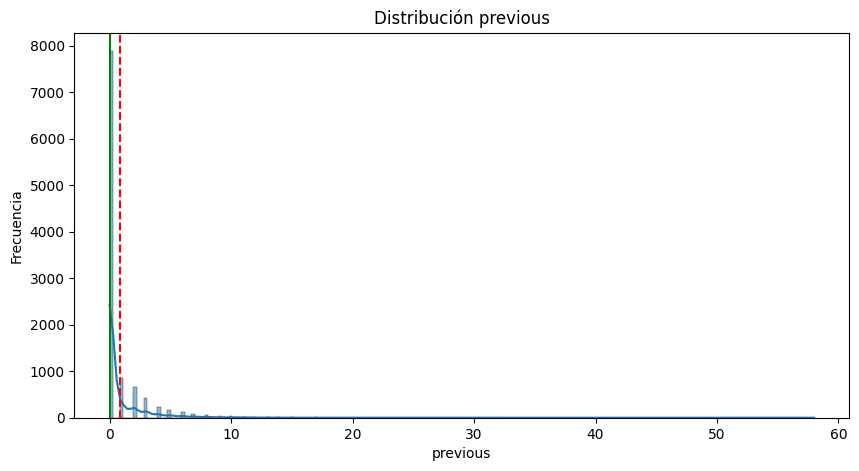

In [15]:
histogramas = auto_visualize_dataframe_histplot(df) 

histogramas

#### 3.2 Visualizacion de datos categoricos

In [16]:
def auto_visualize_dataframe_barplot(df):
    for column in df.columns:

        if (
            pd.api.types.is_string_dtype(df[column])
            or pd.api.types.is_categorical_dtype(df[column])
        ):
            plt.figure(figsize=(10, 5))
            
            ax = df[column].value_counts().head(10).plot(kind="bar")

            plt.title(f"Categorías principales {column}")
            plt.xlabel(column)
            plt.ylabel("Número")
            plt.xticks(rotation=45)

        
            for bar in ax.patches:
                height = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height,
                    f"{int(height)}",
                    ha="center",
                    va="bottom"
                )

            plt.show()


C:\Users\edo\AppData\Local\Temp\ipykernel_27444\2441625650.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(df[column])


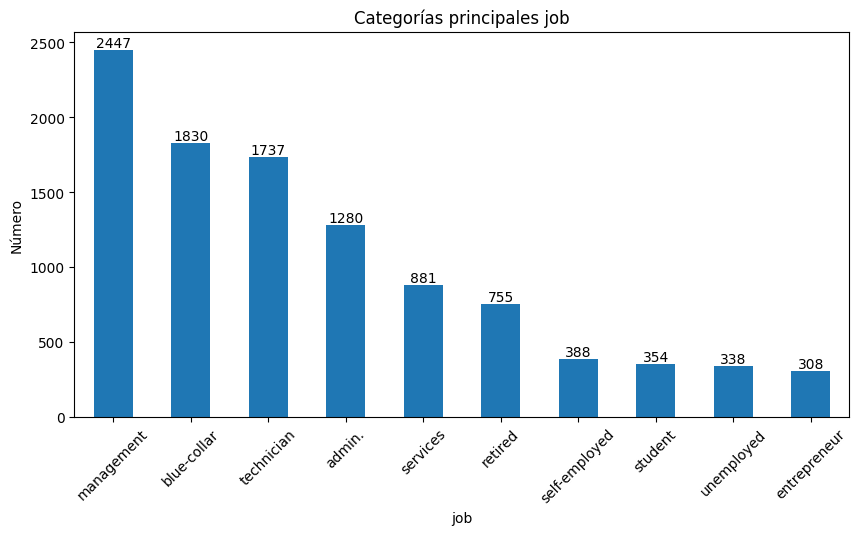

C:\Users\edo\AppData\Local\Temp\ipykernel_27444\2441625650.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(df[column])


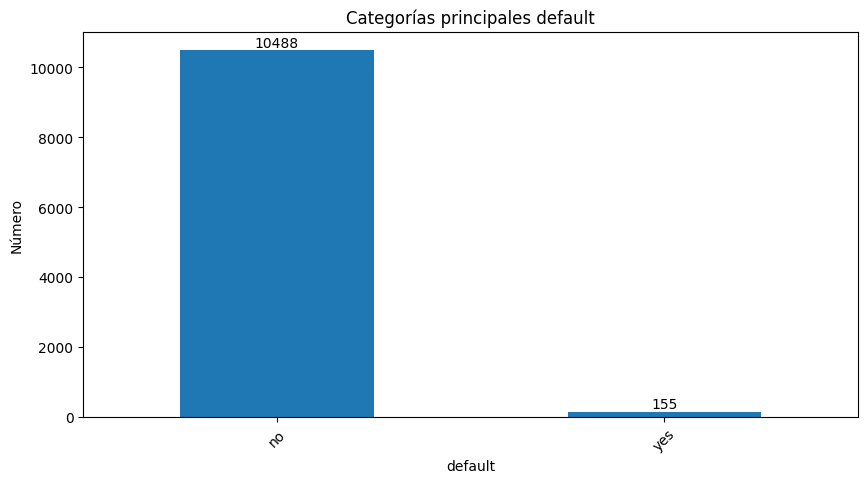

C:\Users\edo\AppData\Local\Temp\ipykernel_27444\2441625650.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(df[column])


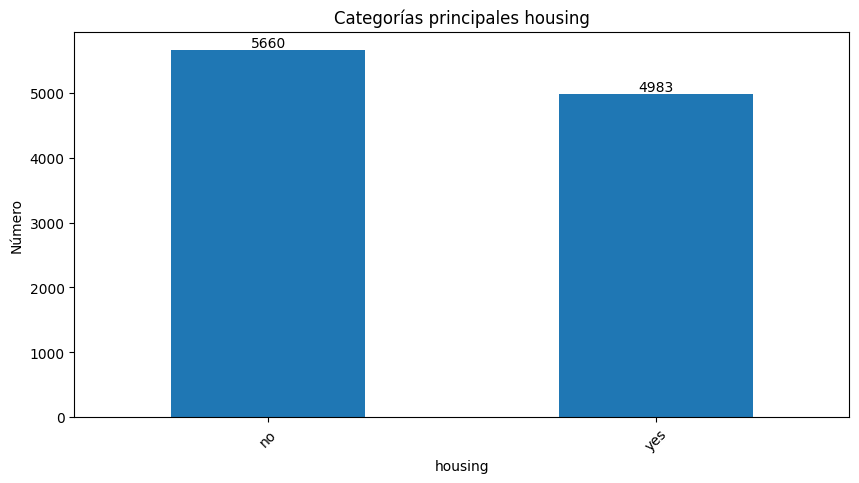

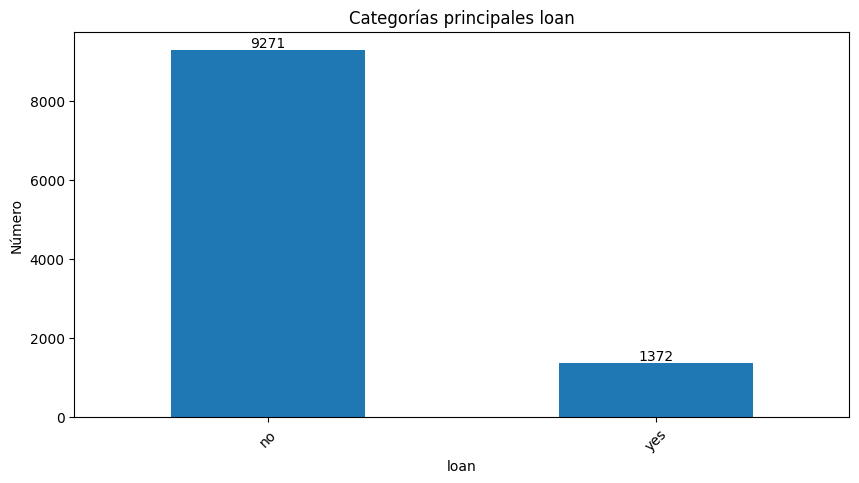

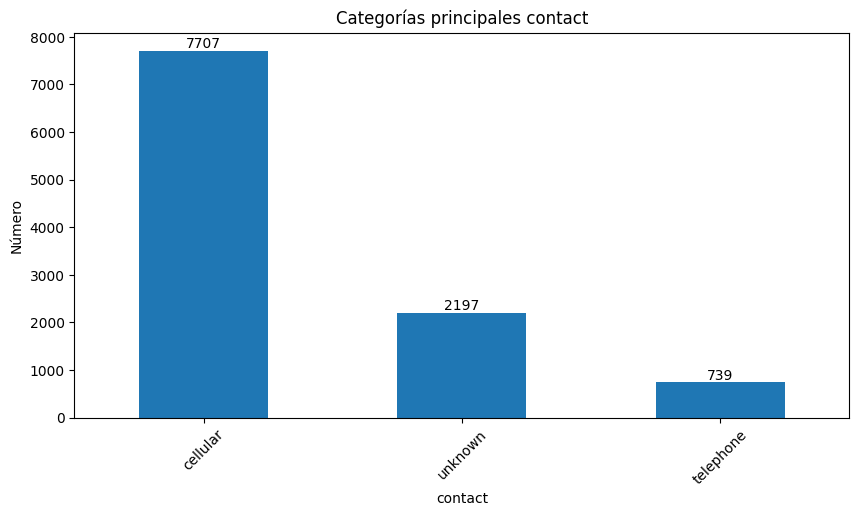

C:\Users\edo\AppData\Local\Temp\ipykernel_27444\2441625650.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(df[column])


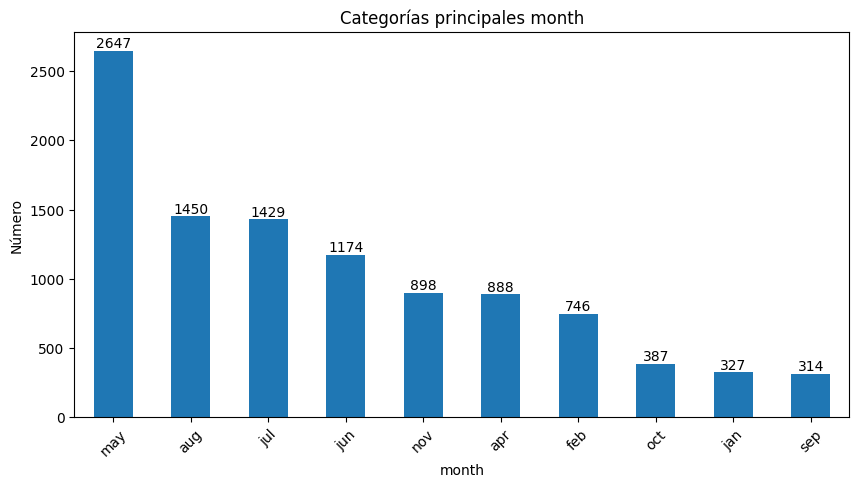

C:\Users\edo\AppData\Local\Temp\ipykernel_27444\2441625650.py:6: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(df[column])


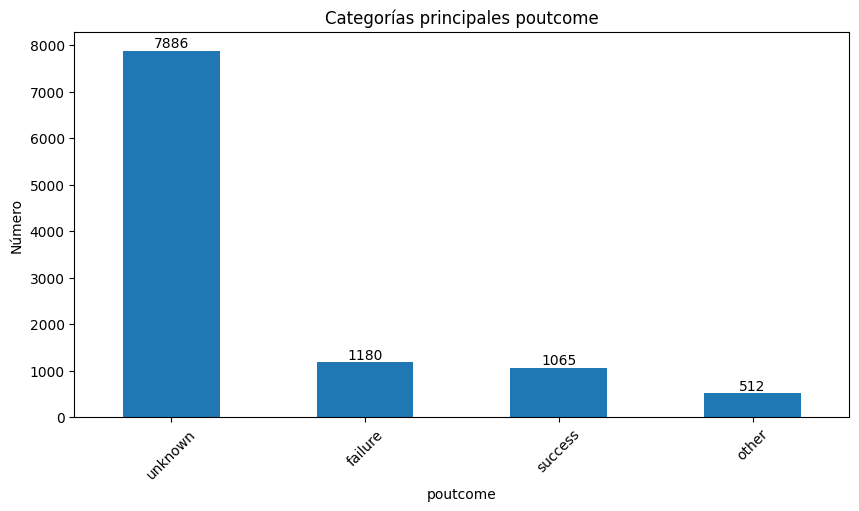

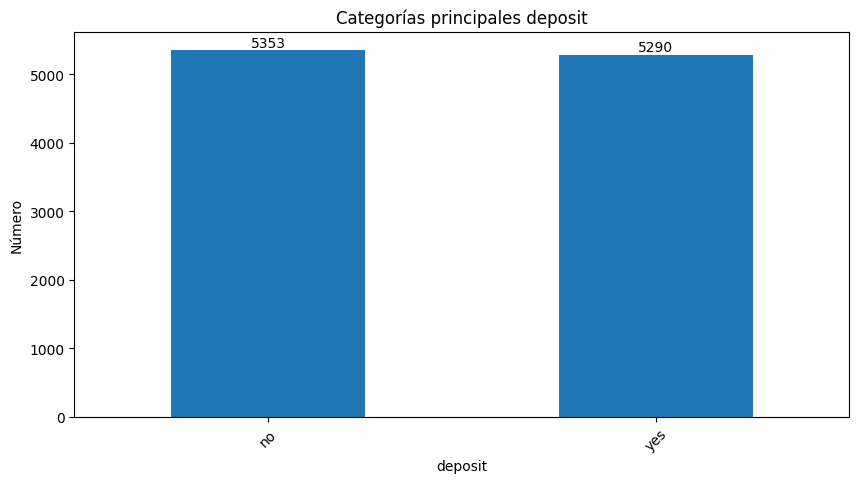

In [17]:
bar_plots = auto_visualize_dataframe_barplot(df)

#### 3.3 resumen del bloque

In [18]:
numeric_cols = df.select_dtypes(include="number").columns.difference(["id"])

In [19]:
def auto_visualize_boxplot(df):
    for col in numeric_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot: {col}")
        plt.xlabel(col)
        plt.show()

    if len(numeric_cols) > 1:
        plt.figure(figsize=(10, 8))
        corr = df[numeric_cols].corr()

        sns.heatmap(
            corr,
            annot=True,
            fmt=".2f",
            cmap="GnBu",
            square=True,
            linewidths=0.5
        )

        plt.title("Correlation heatmap")
        plt.show()


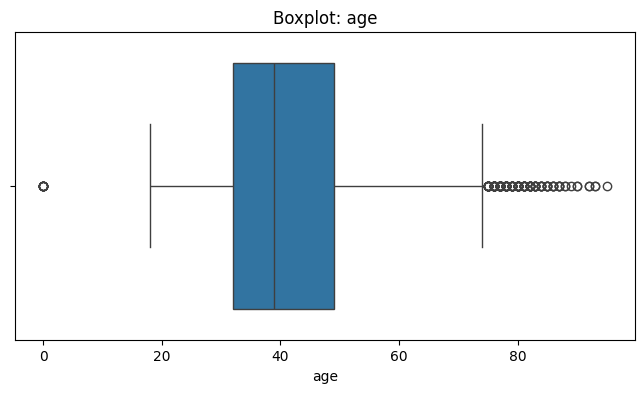

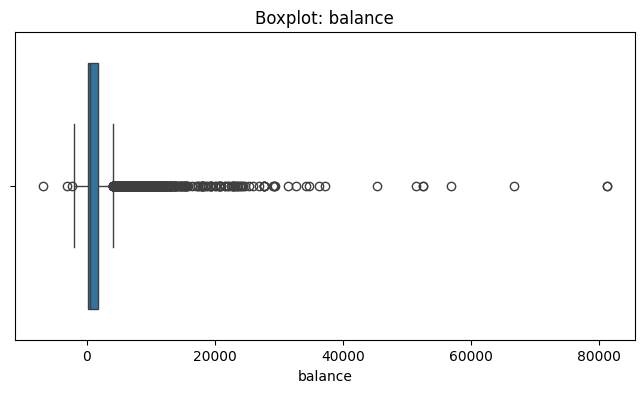

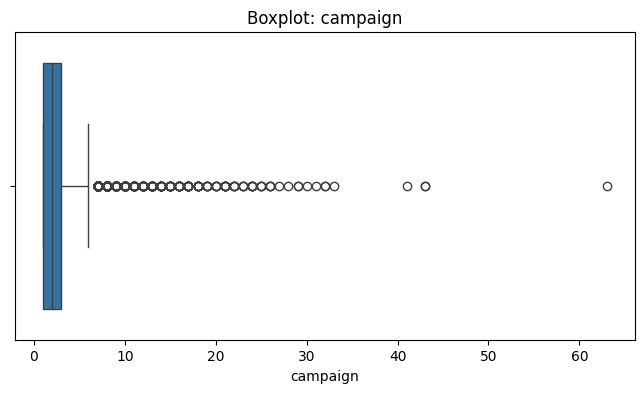

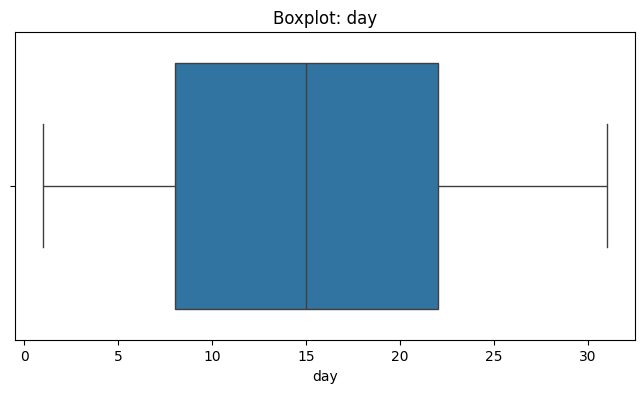

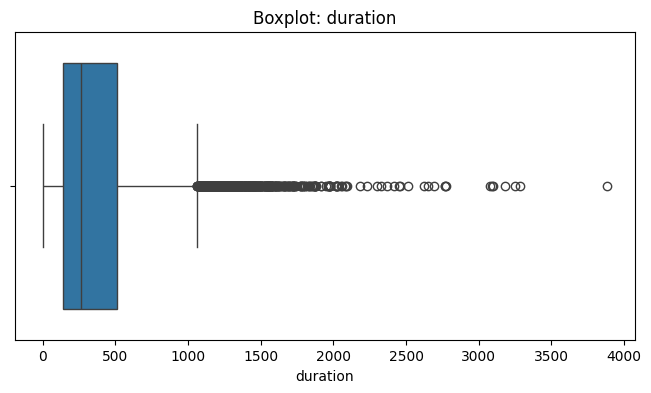

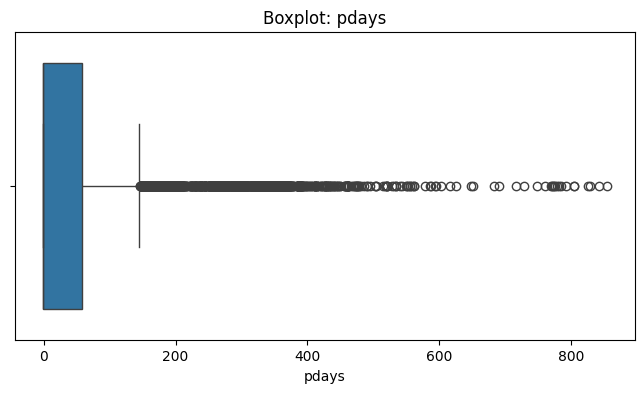

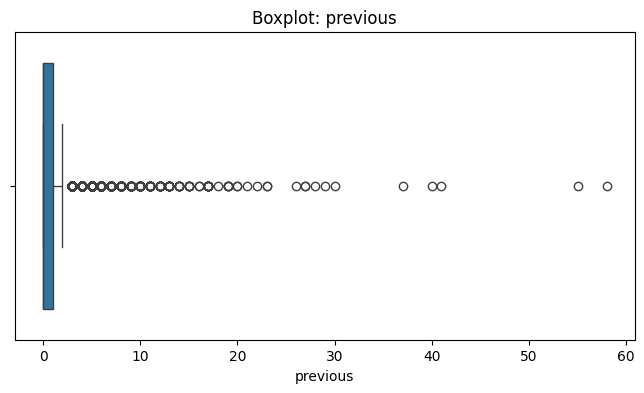

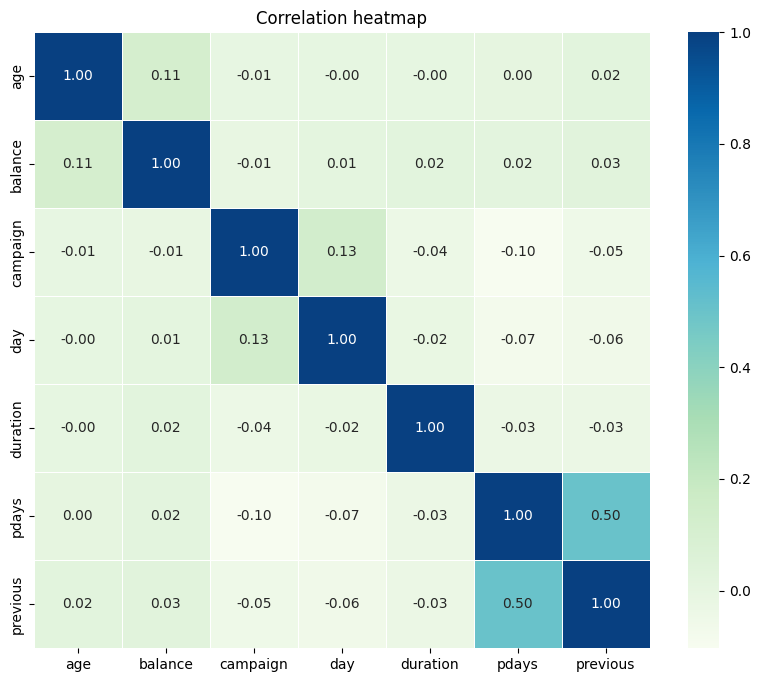

In [20]:
box_plots = auto_visualize_boxplot(df)

## 4. BUSINESS CONTEXT 

#### 4.1 Values numericos asociado con target

Text(0.5, 1.0, 'Violinplot: balance')

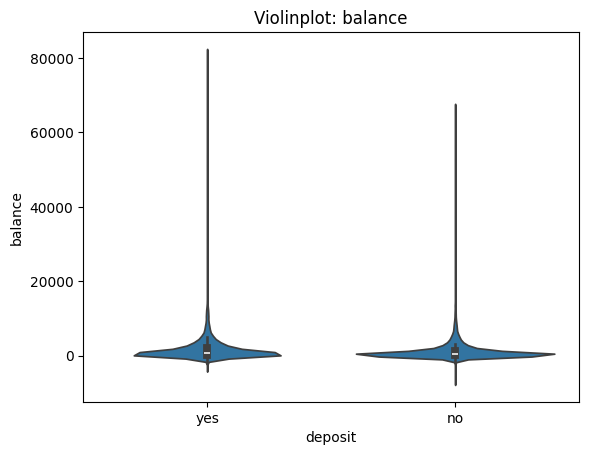

In [21]:
sns.violinplot(x="deposit", y="balance", data=df)
plt.title(f"Violinplot: balance")

In [22]:
df.groupby("deposit")["balance"].agg(["mean", "median", "std"]).round(2)

,mean,median,std
deposit,,,
no,1272.16,418.0,2899.42
yes,1804.37,733.0,3500.78


<Axes: xlabel='deposit', ylabel='duration'>

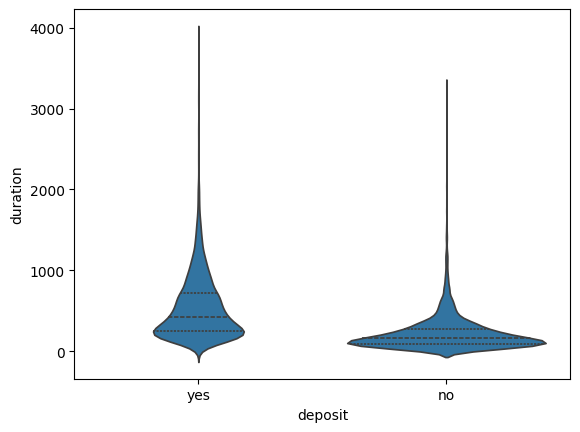

In [23]:
sns.violinplot(x="deposit", y="duration", data=df, inner="quartile")

In [24]:
df.groupby("deposit")["duration"].agg(["mean", "median", "std"]).round(0)

,mean,median,std
deposit,,,
no,222.0,162.0,209.0
yes,537.0,426.0,393.0


<Axes: xlabel='deposit', ylabel='campaign'>

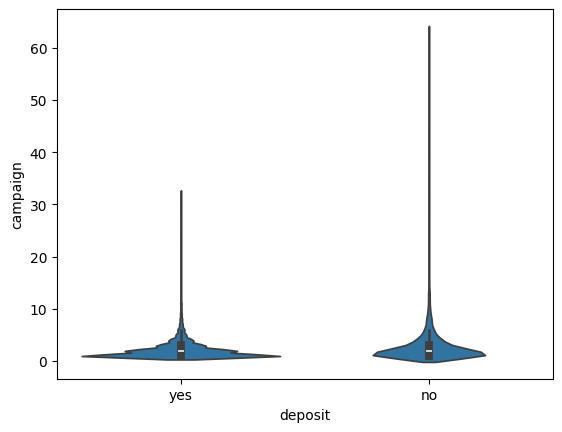

In [25]:
sns.violinplot(x="deposit", y="campaign", data=df)

In [26]:
df.groupby("deposit")["campaign"].agg(["mean", "median", "std"]).round(0)

,mean,median,std
deposit,,,
no,3.0,2.0,3.0
yes,2.0,2.0,2.0


#### 4.2 conversion rate por categoria

In [27]:
(
    df.groupby("job")["deposit"]
      .apply(lambda x: (x == "yes").mean())
      .sort_values(ascending=False)
)


job
student          0.759887
retired          0.683444
unemployed       0.597633
management       0.531671
unknown          0.500000
admin.           0.493750
technician       0.483592
self-employed    0.481959
housemaid        0.424125
services         0.418842
entrepreneur     0.399351
blue-collar      0.386885
Name: deposit, dtype: float64

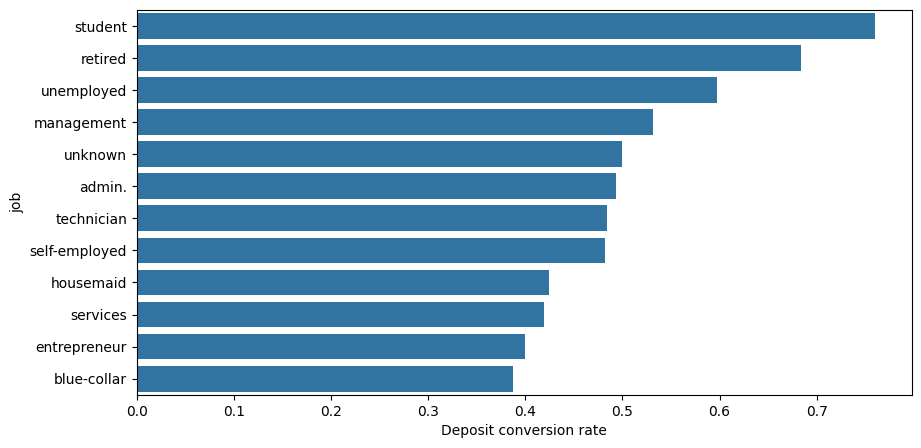

In [28]:
conv = (
    df.groupby("job")["deposit"]
      .apply(lambda x: (x == "yes").mean())
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=conv.values, y=conv.index)
plt.xlabel("Deposit conversion rate")
plt.show()

In [29]:
(
    df.groupby("education")["deposit"]
      .apply(lambda x: (x == "yes").mean())
      .sort_values(ascending=False)
)

education
tertiary     0.565353
unknown      0.532770
secondary    0.469619
primary      0.416490
Name: deposit, dtype: float64

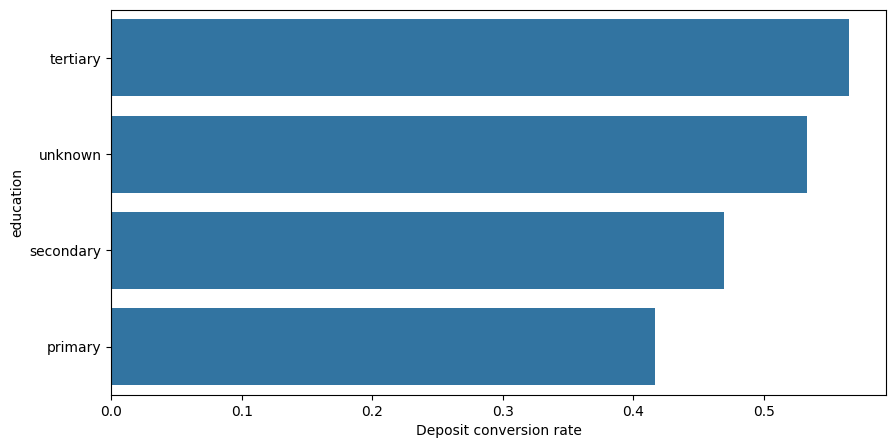

In [30]:
conv = (
    df.groupby("education")["deposit"]
      .apply(lambda x: (x == "yes").mean())
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=conv.values, y=conv.index)
plt.xlabel("Deposit conversion rate")
plt.show()

In [31]:
(
    df.groupby("contact")["deposit"]
      .apply(lambda x: (x == "yes").mean())
      .sort_values(ascending=False)
)

contact
cellular     0.566887
telephone    0.527740
unknown      0.241693
Name: deposit, dtype: float64

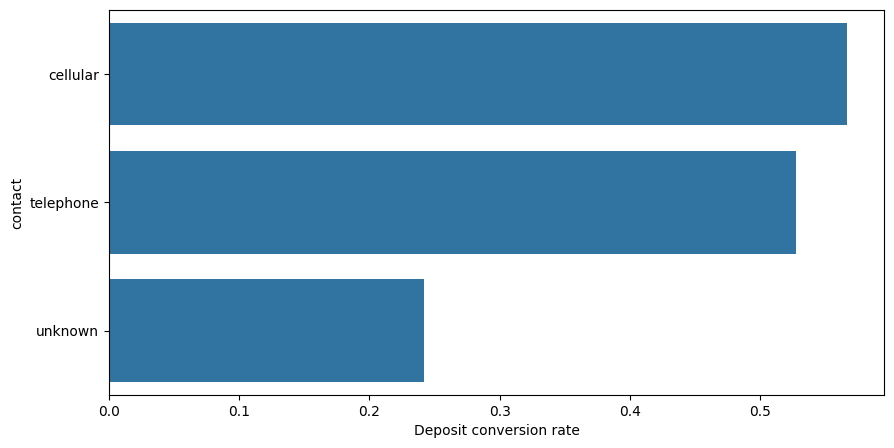

In [32]:
conv = (
    df.groupby("contact")["deposit"]
      .apply(lambda x: (x == "yes").mean())
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=conv.values, y=conv.index)
plt.xlabel("Deposit conversion rate")
plt.show()

## Resumen